In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip '/content/drive/MyDrive/Group D.zip'

Archive:  /content/drive/MyDrive/Group D.zip
   creating: Group D/
   creating: Group D/Dal_End/
  inflating: Group D/Dal_End/AHCR_00001_Dal_End_38.jpg  
  inflating: Group D/Dal_End/AHCR_00001_Dal_End_39.jpg  
  inflating: Group D/Dal_End/AHCR_00001_Dal_End_46.jpg  
  inflating: Group D/Dal_End/AHCR_00001_Dal_End_47.jpg  
  inflating: Group D/Dal_End/AHCR_00002_Dal_End_38.jpg  
  inflating: Group D/Dal_End/AHCR_00002_Dal_End_39.jpg  
  inflating: Group D/Dal_End/AHCR_00002_Dal_End_46.jpg  
  inflating: Group D/Dal_End/AHCR_00002_Dal_End_47.jpg  
  inflating: Group D/Dal_End/AHCR_00003_Dal_End_38.jpg  
  inflating: Group D/Dal_End/AHCR_00003_Dal_End_39.jpg  
  inflating: Group D/Dal_End/AHCR_00003_Dal_End_46.jpg  
  inflating: Group D/Dal_End/AHCR_00003_Dal_End_47.jpg  
  inflating: Group D/Dal_End/AHCR_00004_Dal_End_38.jpg  
  inflating: Group D/Dal_End/AHCR_00004_Dal_End_39.jpg  
  inflating: Group D/Dal_End/AHCR_00004_Dal_End_46.jpg  
  inflating: Group D/Dal_End/AHCR_00004_Dal_End_

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

img_width, img_height = 150, 150
data_dir = "/content/Group D"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))  

    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):  
            for img_file in os.listdir(group_path): 
                img_path = os.path.join(group_path, img_file)
                try:
                    img = tf.keras.preprocessing.image.load_img(
                        img_path, target_size=(img_width, img_height), color_mode='grayscale'
                    )
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_file} in {group_name}: {e}")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images) == 0:
    raise ValueError("No images were loaded. Check the data directory and file paths.")

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(f"Training samples: {x_train.shape[0]}, Testing samples: {x_test.shape[0]}")
print(f"Number of classes: {num_classes}")


Training samples: 1521, Testing samples: 381
Number of classes: 4


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 83s 836ms/step - accuracy: 0.2522 - loss: 1.4310 - val_accuracy: 0.3780 - val_loss: 1.2537
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 828ms/step - accuracy: 0.4069 - loss: 1.2334 - val_accuracy: 0.4882 - val_loss: 1.0643
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 80s 806ms/step - accuracy: 0.5377 - loss: 0.9905 - val_accuracy: 0.7428 - val_loss: 0.7500
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 87s 862ms/step - accuracy: 0.6802 - loss: 0.7845 - val_accuracy: 0.8031 - val_loss: 0.6155
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 836ms/step - accuracy: 0.7691 - loss: 0.6467 - val_accuracy: 0.8845 - val_loss: 0.3421
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 823ms/step - accuracy: 0.8575 - loss: 0.4401 - val_accuracy: 0.9081 - val_loss: 0.3032
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 76s 790ms/step - accuracy: 0.8816 - loss: 0.3616 - val_accuracy: 0.9318 - val_loss: 0.3033
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 84s 813ms/step - accuracy: 0.8934 - loss: 0.3465 - val_accuracy: 0.92

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.9471 - loss: 0.2106
Train Accuracy: 95.86%
Test Accuracy: 96.06%


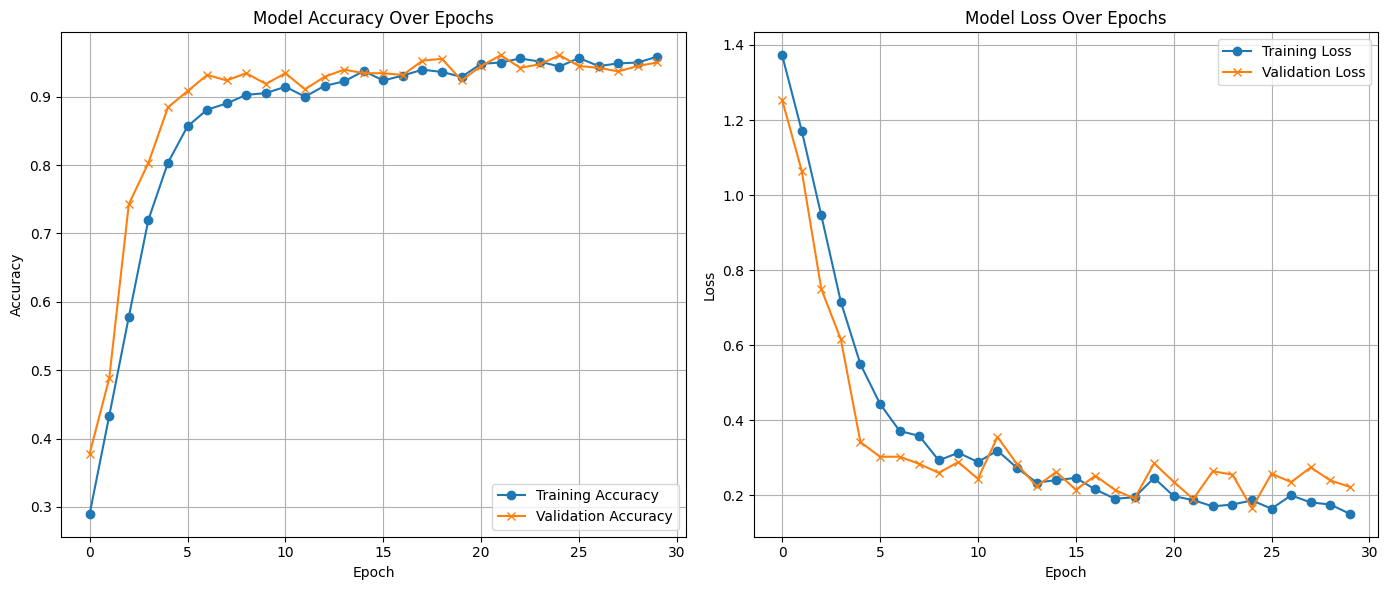

In [ ]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 345ms/step


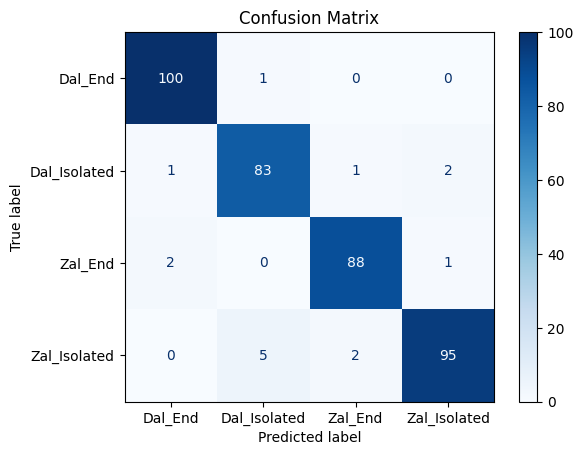

In [ ]:

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 756ms/step


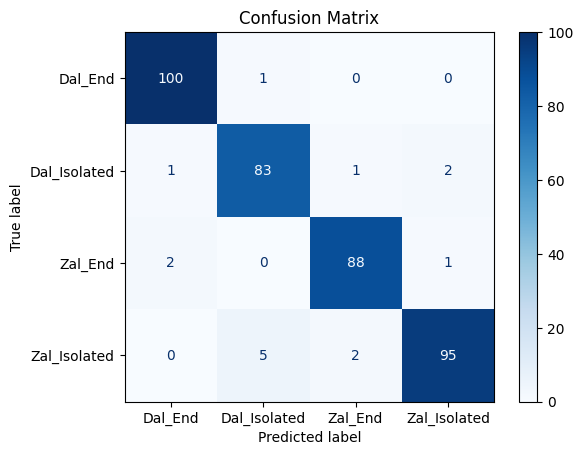

Number of incorrect predictions: 15


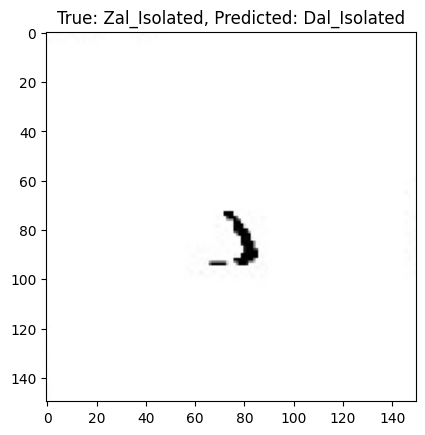

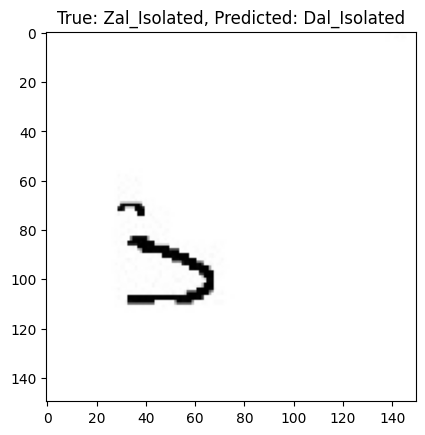

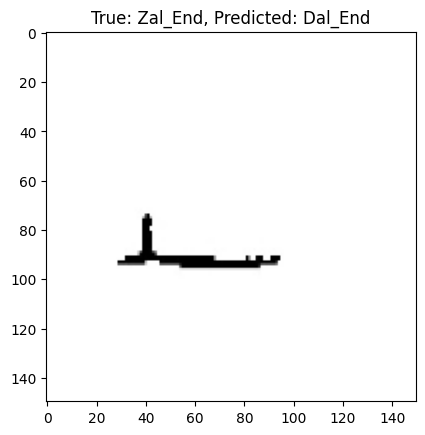

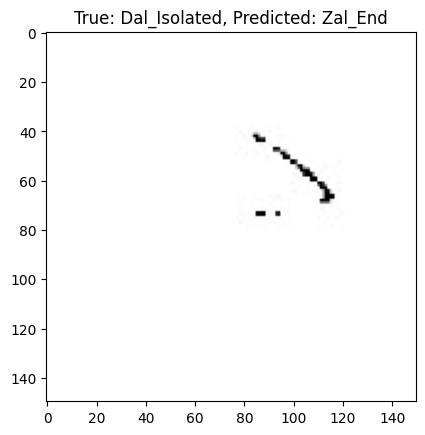

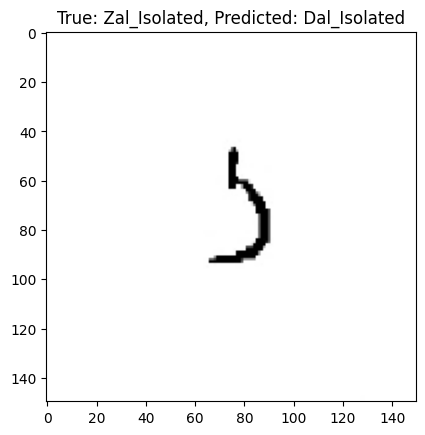

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### reduce data augmentation(width_shift_range,height_shift_range,zoom_range ) and remove dropout

In [103]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.01,
    height_shift_range=0.01,
    zoom_range=0.01,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [104]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

In [105]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.2906 - loss: 1.5175 - val_accuracy: 0.5066 - val_loss: 1.0843
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5293 - loss: 1.0377 - val_accuracy: 0.6457 - val_loss: 0.7856
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7152 - loss: 0.6757 - val_accuracy: 0.8084 - val_loss: 0.5916
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8311 - loss: 0.4472 - val_accuracy: 0.8215 - val_loss: 0.5530
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8641 - loss: 0.4033 - val_accuracy: 0.8819 - val_loss: 0.3956
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9205 - loss: 0.2568 - val_accuracy: 0.8871 - val_loss: 0.3490
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9470 - loss: 0.1754 - val_accuracy: 0.8766 - val_loss: 0.3581
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9562 - loss: 0.1580 - val_accuracy: 0.8714 - 

In [107]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9333 - loss: 0.2350
Train Accuracy: 97.70%
Test Accuracy: 92.39%


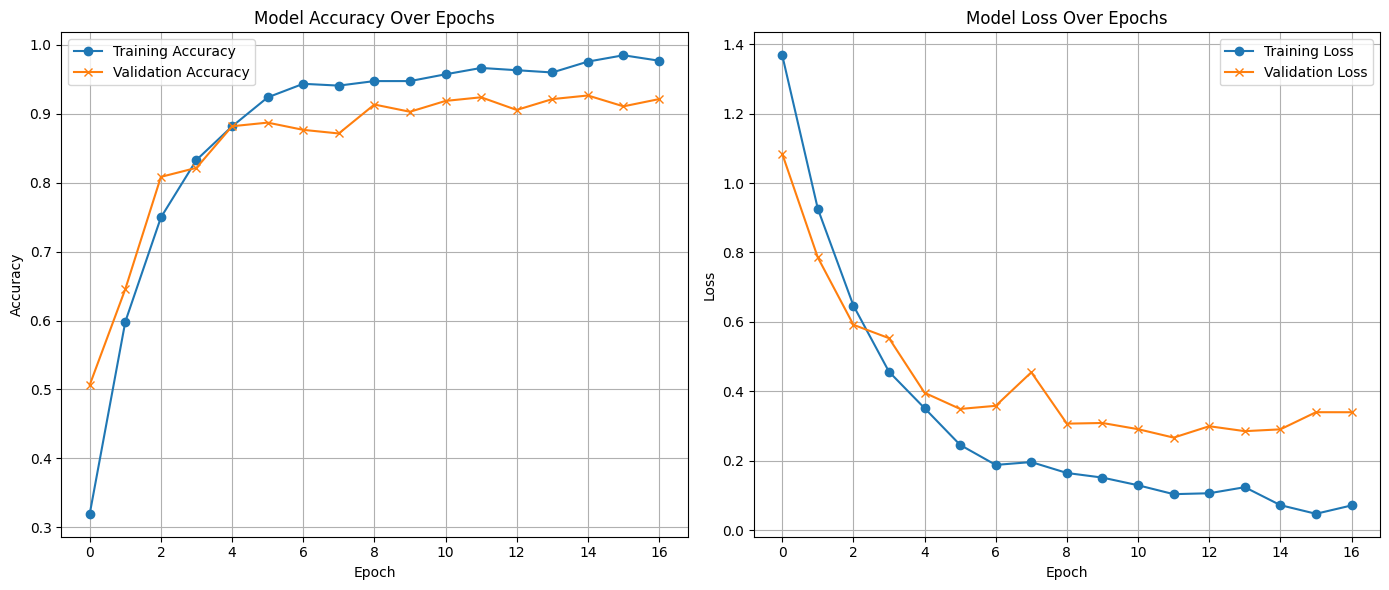

In [108]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


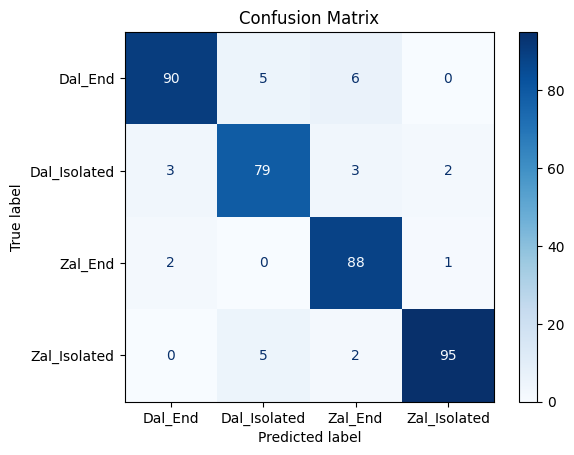

Number of incorrect predictions: 29


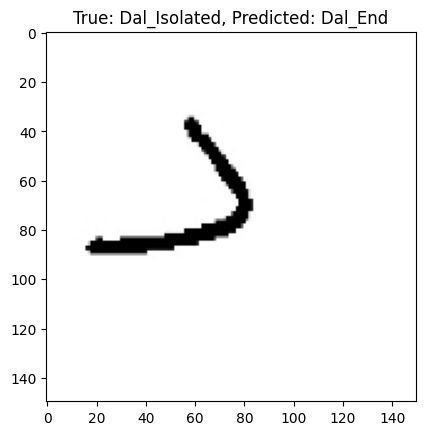

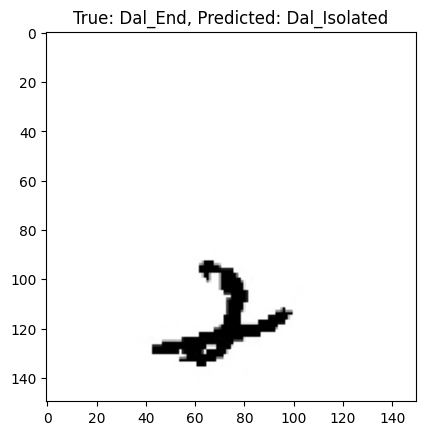

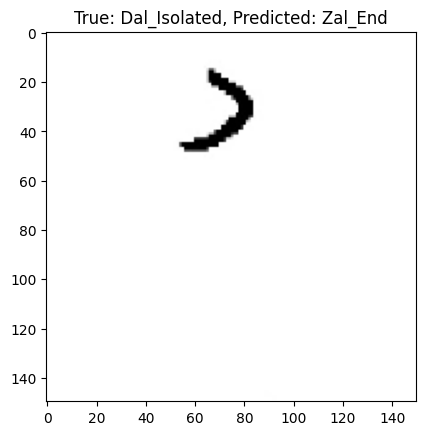

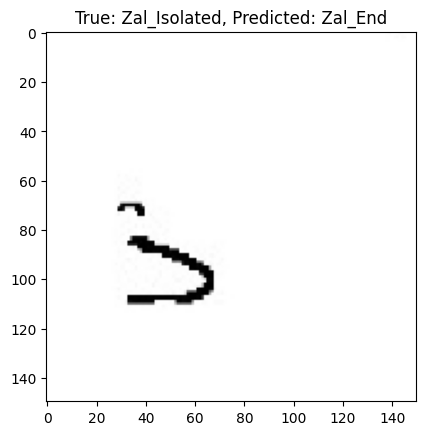

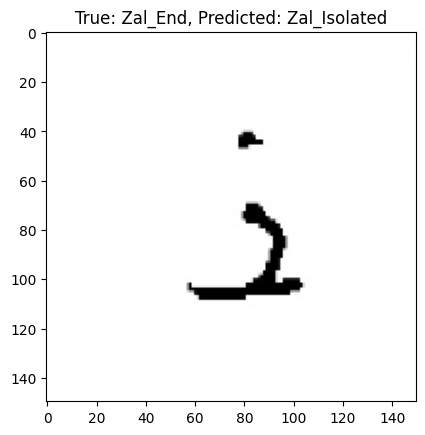

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### reduce data augmentation (rotation range)

In [131]:
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [132]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [133]:
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.2330 - loss: 1.4297 - val_accuracy: 0.2808 - val_loss: 1.3776
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.3069 - loss: 1.3621 - val_accuracy: 0.4121 - val_loss: 1.2470
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.4695 - loss: 1.2203 - val_accuracy: 0.5407 - val_loss: 1.0350
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5261 - loss: 1.0724 - val_accuracy: 0.5459 - val_loss: 1.0863
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.5998 - loss: 0.9821 - val_accuracy: 0.6142 - val_loss: 0.9666
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.6272 - loss: 0.9270 - val_accuracy: 0.6168 - val_loss: 0.9476
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7016 - loss: 0.7974 - val_accuracy: 0.6850 - val_loss: 0.8540
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.6751 - loss: 0.7832 - val_accuracy: 0.7087 -

In [134]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8699 - loss: 0.4158
Train Accuracy: 86.59%
Test Accuracy: 86.61%


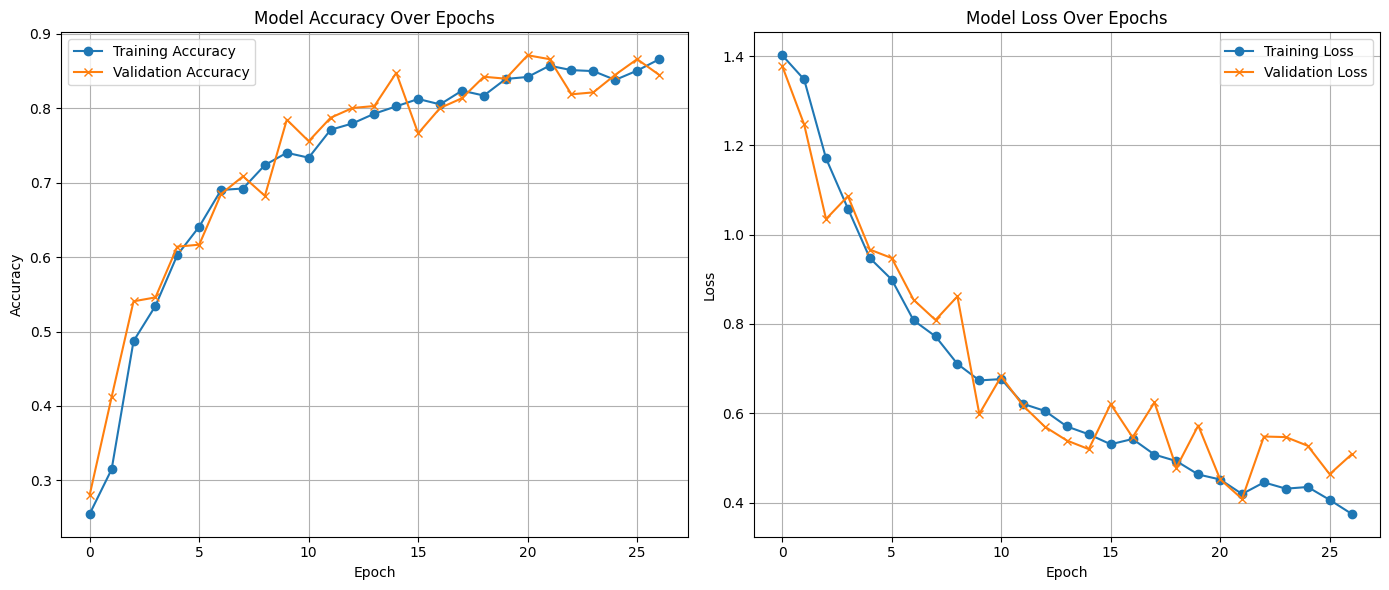

In [135]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


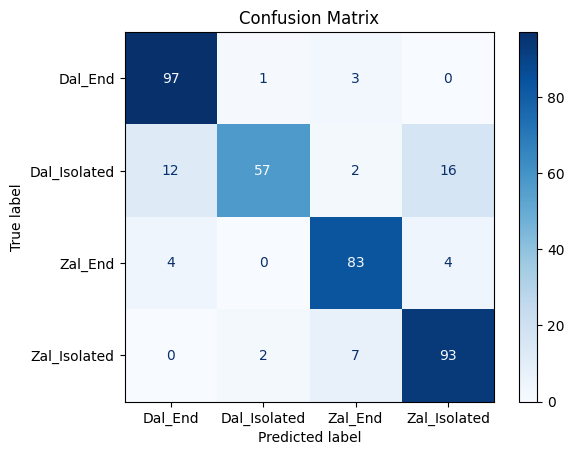

Number of incorrect predictions: 51


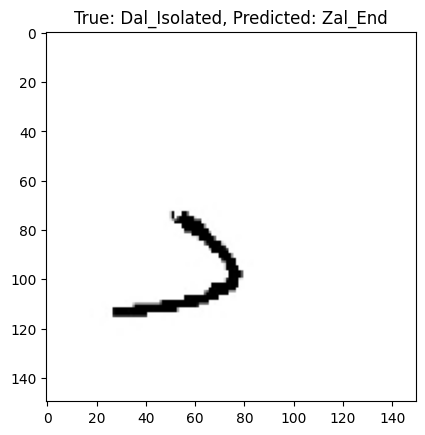

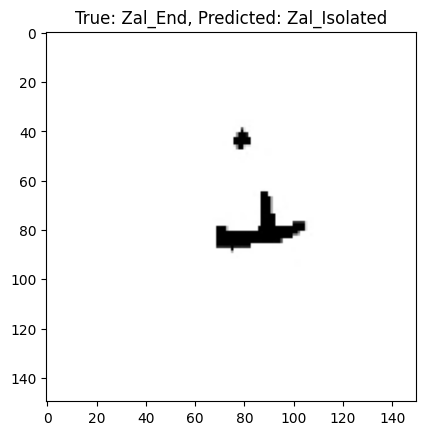

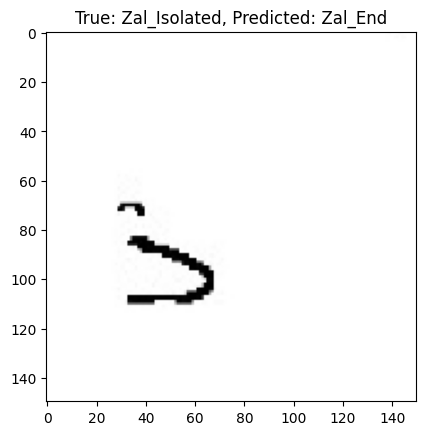

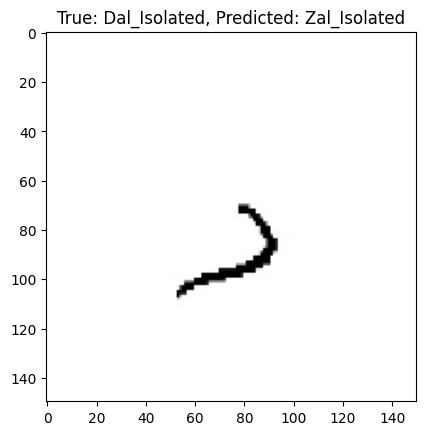

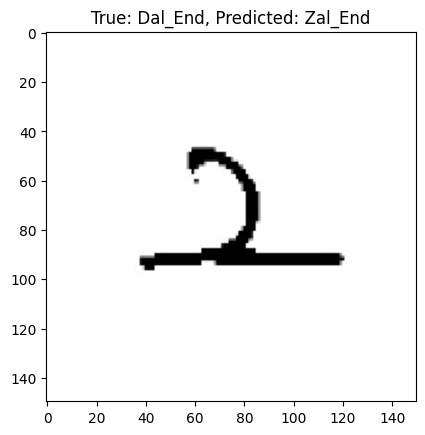

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [137]:
model.save("GrpD.keras")